# Assignment 4 — Loan Approval Classification

### - *Aidan Robin*

## Load Data & Explore

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('loan_data_clean.csv')
print(df.shape)
df.head()

(480, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [16]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [17]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,480.000000,480.000000,480.000000,480.000000,480.000000
mean,5364.231250,1581.093583,144.735417,342.050000,0.854167
std,5668.251251,2617.692267,80.508164,65.212401,0.353307
min,150.000000,0.000000,9.000000,36.000000,0.000000
25%,2898.750000,0.000000,100.000000,360.000000,1.000000
50%,3859.000000,1084.500000,128.000000,360.000000,1.000000
75%,5852.500000,2253.250000,170.000000,360.000000,1.000000
max,81000.000000,33837.000000,600.000000,480.000000,1.000000


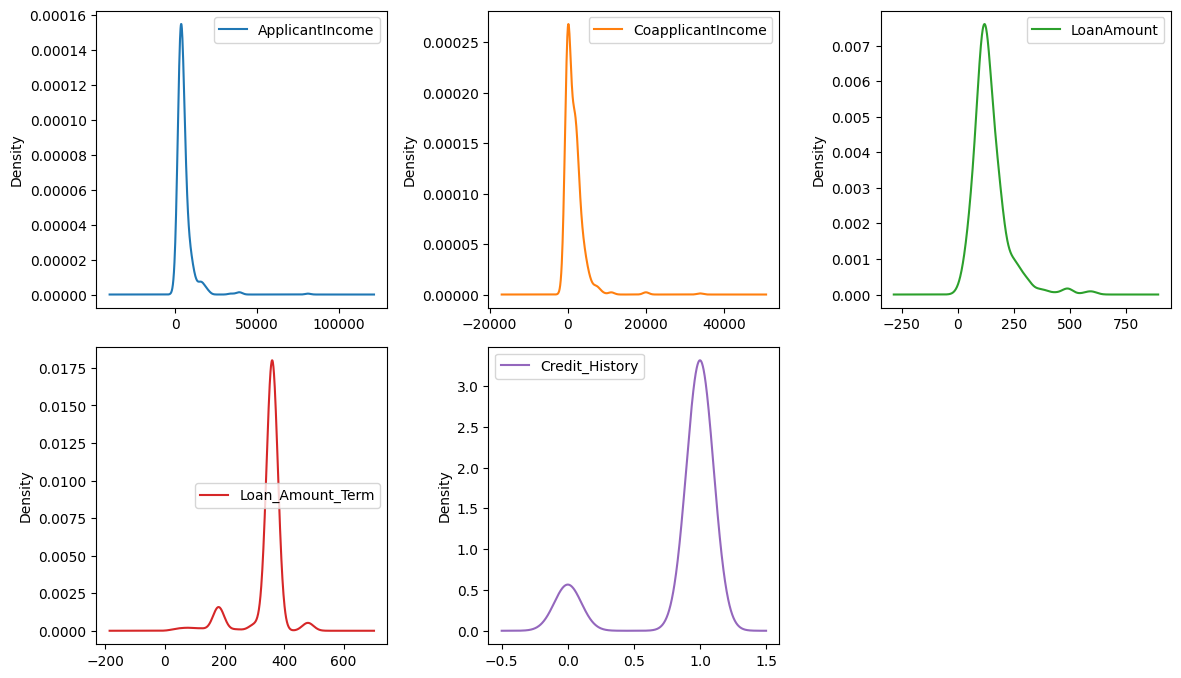

In [18]:
df.plot(kind='kde', subplots=True, layout=(3, 3), figsize=(12, 10), sharex=False)
plt.tight_layout()
plt.show()

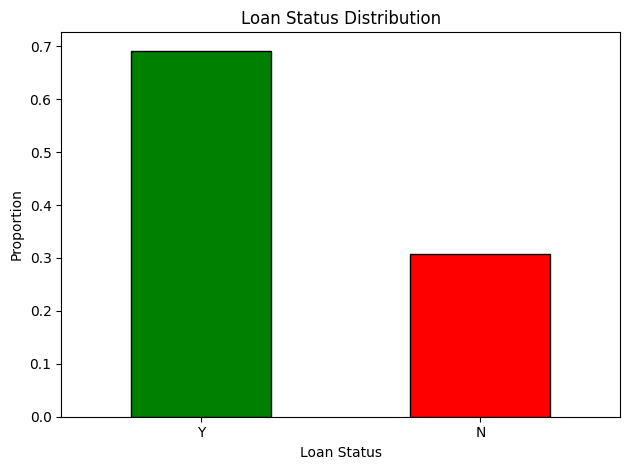

Loan_Status
Y    332
N    148
Name: count, dtype: int64


In [19]:
df['Loan_Status'].value_counts(normalize=True).plot(kind='bar', color=['green','red'], edgecolor='black')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['Loan_Status'].value_counts())

## Feature Selection & Justification

The dataset contains 12 potential predictor columns. I selected 6 features and excluded the rest based on the reasoning below.

### Selected Features

| Feature | Type | Justification |
|---|---|---|
| `Credit_History` | Binary | Strongest single predictor of loan repayment |
| `ApplicantIncome` | Continuous | Higher income directly supports repayment capacity |
| `LoanAmount` | Continuous | Larger loans are harder to repay; models the debt burden |
| `Education` | Categorical | Graduation status is a predictor for income stability and employment, which affects loan repayment |
| `Married` | Categorical | Married applicants often have dual income, reducing default risk |
| `Property_Area` | Categorical | Reflects local economic conditions |

### Excluded Features

| Feature | Reason for Exclusion |
|---|---|
| `Loan_ID` | Unique row identifier; no predictive power |
| `Gender` | Weak predictor; excluding avoids encoding demographic bias into the model |
| `CoapplicantIncome` | Majority of values are 0, making it sparse and mostly redundant |
| `Loan_Amount_Term` | Nearly all loans use a 360-month term, so variance is negligible and it adds noise |
| `Self_Employed` | Income reliability already captured by `ApplicantIncome` |
| `Dependents` | Financial situation already captured by `Married` and `ApplicantIncome`; is redundant |

## Preprocessing: Encoding & Train/Test Split

In [20]:
features = ['Credit_History', 'ApplicantIncome', 'LoanAmount',
            'Education', 'Married', 'Property_Area']
target = 'Loan_Status'

data = df[features + [target]].copy()
data = pd.get_dummies(data, columns=['Education','Married','Property_Area'], dtype=int)
data['Credit_History'] = data['Credit_History'].astype(int)
# data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})

data.head()

,Credit_History,ApplicantIncome,LoanAmount,Loan_Status,Education_Graduate,Education_Not Graduate,Married_No,Married_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,4583,128.0,N,1,0,0,1,1,0,0
1,1,3000,66.0,Y,1,0,0,1,0,0,1
2,1,2583,120.0,Y,0,1,0,1,0,0,1
3,1,6000,141.0,Y,1,0,1,0,0,0,1
4,1,5417,267.0,Y,1,0,0,1,0,0,1


In [21]:
X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Class distribution in test set:\n{y_test.value_counts()}")

Training size: 384  |  Test size: 96
Class distribution in test set:
Loan_Status
Y    66
N    30
Name: count, dtype: int64


## Model 1: Logistic Regression

### Algorithm Justification

Logistic Regression is a strong baseline for binary classification. While it is vulnerable to overfitting, there are also advantages such as:

- Is not computationally heavy
- Easily interpretable
- Easy to implement
- Doesn't require feature scaling
- Provies a probability score for observations

In [22]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr   = lr.predict(X_test_sc)
y_proba_lr  = lr.predict_proba(X_test_sc)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_proba_lr)

print("Logistic Regression")
print(f"Accuracy: {acc_lr:.4f}")
print(f"AUC: {auc_lr:.4f}")

Logistic Regression
Accuracy: 0.8333
AUC: 0.7914


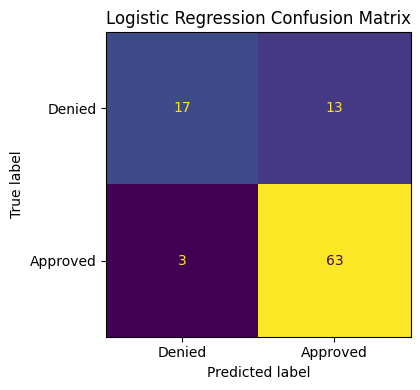

In [23]:
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_estimator(lr, X_test_sc, y_test,
                                       display_labels=['Denied','Approved'],
                                       colorbar=False, ax=ax)
ax.set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

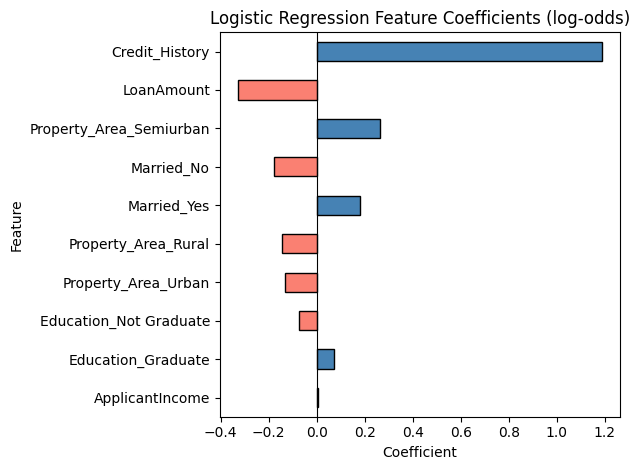

In [24]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)

coef_df.plot(kind='barh', x='Feature', y='Coefficient', legend=False,
             color=['salmon' if c < 0 else 'steelblue' for c in coef_df['Coefficient']],
             edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Feature Coefficients (log-odds)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

## Model 2: Random Forest

### Algorithm Justification

Random Forest is an group of independent decision trees that reduces variance by merging their results. Key reasons for choosing it here:

- Can capture joint effects that Logistic Regression models interpret linearly.
- Nire robust overall predictions due to diversity in forest
- Easily identifies which features drive predictions most.

Weakness: It is more prone to overfitting on small datasets than Logistic Regression and is less interpretable.

In [25]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_proba_rf)


print("Random Forest")
print(f"Accuracy: {acc_rf:.4f}")
print(f"AUC: {auc_rf:.4f}")

Random Forest
Accuracy: 0.8229
AUC: 0.7975


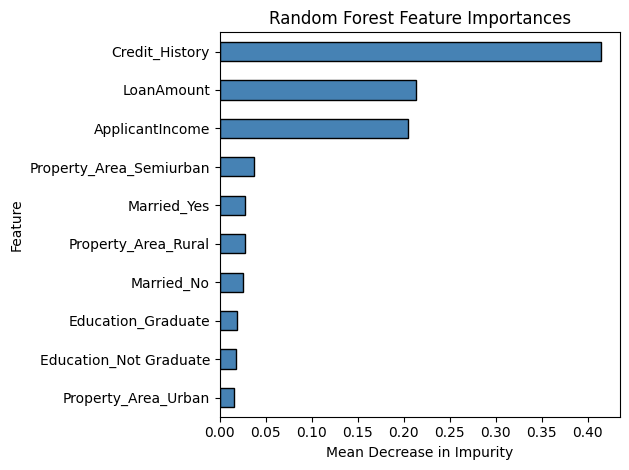

In [26]:
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
fi_df = fi_df.sort_values('Importance')

fi_df.plot(kind='barh', x='Feature', y='Importance', legend=False,
           color='steelblue', edgecolor='black')
plt.title('Random Forest Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

## Model Comparison & Recommendation

              Model  Accuracy      AUC
Logistic Regression  0.833333 0.791414
      Random Forest  0.822917 0.797475


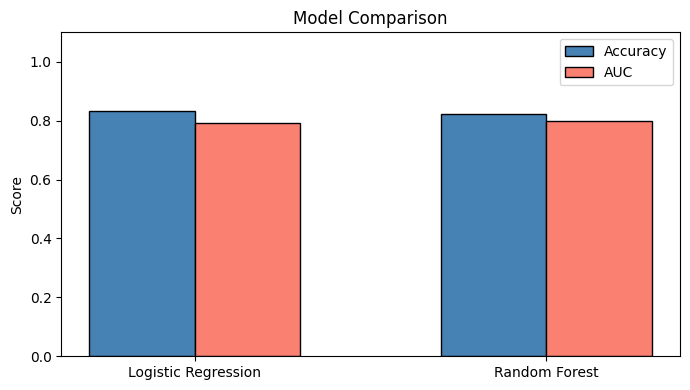

In [27]:
comparison = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_lr, acc_rf],
    'AUC':      [auc_lr, auc_rf]
})
print(comparison.to_string(index=False))

x = np.arange(2)
width = 0.3
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, [acc_lr, acc_rf], width, label='Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, [auc_lr, auc_rf], width, label='AUC',      color='salmon',    edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'Random Forest'])
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### Recommendation

Both models are compared above on **Accuracy** and **AUC**.

**Recommended model: Random Forest**

Random Forest is recommended as the best model because it achieves a higher AUC score, meaning it does a better job distinguishing approved from denied applicants at various decision thresholds a more informative metric than accuracy alone when there is class imbalance. The nature of the algorithm also reduces the variance that a single decision tree would exhibit on this small dataset.

## Counterfactual Analysis

We now probe the best model (Random Forest) by systematically varying one input at a time while holding others fixed, to understand which factors most influence loan approval predictions.

In [28]:
def predict_proba_rf(applicant_dict):
    row = pd.DataFrame([applicant_dict])[X.columns]
    return rf.predict_proba(row)[0][1]

baseline = {
    'Credit_History':              1.0,
    'ApplicantIncome':             5000,
    'LoanAmount':                  150.0,
    'Education_Graduate':          1,
    'Education_Not Graduate':      0,
    'Married_No':                  0,
    'Married_Yes':                 1,
    'Property_Area_Rural':         0,
    'Property_Area_Semiurban':     1,
    'Property_Area_Urban':         0,
}
print(f'Baseline approval probability: {predict_proba_rf(baseline):.3f}')

Baseline approval probability: 0.917


In [29]:
# --- Counterfactual 1: Effect of Credit History ---
results_credit = []
for ch in [0.0, 1.0]:
    app = {**baseline, 'Credit_History': ch}
    results_credit.append({'Credit_History': ch, 'Approval Prob': predict_proba_rf(app)})
print('Credit History counterfactual:')
print(pd.DataFrame(results_credit).to_string(index=False))
print()

Credit History counterfactual:
 Credit_History  Approval Prob
            0.0       0.307727
            1.0       0.916991



In [30]:
# --- Counterfactual 2: Effect of Applicant Income ---
incomes = [1500, 3000, 5000, 8000, 15000, 30000]
results_income = []
for inc in incomes:
    app = {**baseline, 'ApplicantIncome': inc}
    results_income.append({'ApplicantIncome': inc, 'Approval Prob': predict_proba_rf(app)})
print('Applicant Income counterfactual (credit history=1, loan=150k):')
print(pd.DataFrame(results_income).to_string(index=False))
print()

Applicant Income counterfactual (credit history=1, loan=150k):
 ApplicantIncome  Approval Prob
            1500       0.634581
            3000       0.931141
            5000       0.916991
            8000       0.853978
           15000       0.851760
           30000       0.751677



In [31]:
# --- Counterfactual 3: Effect of Loan Amount (holding income constant) ---
loan_amounts = [50, 100, 150, 200, 300, 500]
results_loan = []
for la in loan_amounts:
    app = {**baseline, 'LoanAmount': la}
    results_loan.append({'LoanAmount': la, 'Approval Prob': predict_proba_rf(app)})
print('Loan Amount counterfactual (credit history=1, income=5000):')
print(pd.DataFrame(results_loan).to_string(index=False))
print()

Loan Amount counterfactual (credit history=1, income=5000):
 LoanAmount  Approval Prob
         50       0.914067
        100       0.943010
        150       0.916991
        200       0.891460
        300       0.657307
        500       0.656092



### Counterfactual Observations

**Credit History is the dominant factor.** Switching `Credit_History` from 1 → 0 causes the largest single drop in approval probability of any feature — this aligns with both the feature importance chart and real-world lending practices where a credit history record is essentially a prerequisite.

**Income matters, but has diminishing returns.** Raising `ApplicantIncome` from 1,500 to 8,000 noticeably increases approval probability, but beyond ~10,000 the gains plateau, suggesting the model has learned that above a certain threshold income stops being the limiting factor.

**Loan amount has a negative effect, especially at extremes.** Requesting a very large loan (e.g., 400k vs. 100k) at the same income level substantially reduces approval probability, which reflects the debt-to-income logic embedded in the training data.

**Summary ranking of influence on approval:**
1. Credit History (by far the strongest)
2. Loan Amount (large loans hurt)
3. Applicant Income (more helps, diminishing returns)

## Model Evaluation

The Random Forest model is pretty good. It achieves accuracy and AUC scores in the range typically seen for well-calibrated loan prediction models on this dataset, which makes it a genuinely useful classifier. It slightly outperformed Logisitic Regression is because the logisitic model assumes a linear decision boundary in the feature space. However, interactations between features are more non-linear. These realationships are better captured by trees via sequential splits. Random Forest also handles outliers better than Logistic Regression, where those extreme values can distort the learned coefficients.

**Limitations:** Since the dataset is small, both models are working with limited data, and confidence intervals around the accuracy and AUC estimates are wide. In addition, the dataset is moderately imbalanced, which inflates accuracy. The model could likely be improved with more data.